In [1]:
# ==========================================
# Cell 1: Install / import dependencies
# ==========================================

from pathlib import Path
import sys

import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'main.py').exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import DEFAULT_SEED, make_params
from initialization import initialize_model
from main import run_one_round
from utils import set_random_seed
from visualization import (
    plot_final_opinion_distribution,
    plot_network_and_homophily,
    plot_opinion_leaders,
    plot_time_series_summaries,
    prepare_graph_for_visualization,
)


In [2]:
# ==========================================
# Cell 2: Random seed and helper functions
# ==========================================

SEED = DEFAULT_SEED
rng = set_random_seed(SEED)
SEED


42

In [3]:
# ==========================================
# Cell 3: Define model parameters
# ==========================================

params = make_params()
params


{'N': 1000,
 'm_BA': 3,
 'leader_in_degree_threshold': 20,
 'T_rounds': 80,
 'opinion_mean': 0.0,
 'opinion_std': 0.35,
 'Abar_low': 0.2,
 'Abar_high': 0.8,
 'rho_A': 0.6,
 'omega1': 0.1,
 'omega2': 0.2,
 'omega3': 0.05,
 'N_E': 10.0,
 'kappa': 2.0,
 'alpha0': -2.0,
 'alpha1': 1.8,
 'alpha2': 1.2,
 'alpha3': 0.25,
 'alpha_B': 1.5,
 'beta1': 0.6,
 'beta2': 0.4,
 'beta3': 0.5,
 'beta4': 0.7,
 'c0': 0.55,
 'epsilon_std': 0.15,
 'epsilon_ambiguity': 0.5,
 'gamma0': 0.15,
 'gamma1': 0.55,
 'gamma2': 0.35,
 'gamma3': 0.45,
 'gamma4': 0.25,
 'c_C': 0.1,
 'eta_C_std': 0.12,
 'delta0': 0.05,
 'delta1': 0.55,
 'delta2': 0.45,
 'delta3': 0.4,
 'delta4': 0.3,
 'c_T': 0.18,
 'eta_T_std': 0.12,
 'p_O': 0.02,
 'beta0_diff': -3.2,
 'beta1_diff': 0.8,
 'beta2_diff': 0.7,
 'max_read_capacity': 8,
 'w_o': 1.0,
 'w_l': 1.5,
 'gamma_R': 0.01,
 'gamma_A': 0.008,
 'gamma_B': 0.012,
 'gamma_R_L': 0.006,
 'gamma_A_L': 0.004,
 'gamma_B_L': 0.006,
 'a1': 1.0,
 'a2': 0.6,
 'a3': 0.7,
 'a4': 1.2,
 'b_T': 0.5,
 'b_

In [4]:
# ==========================================
# Cell 4: Initialize BA network and agent states
# ==========================================

G, G_initial_undirected, agents, blocks, pos = initialize_model(params, seed=SEED)

print('Initialization finished.')
print(f"Nodes: {G.number_of_nodes()}")
print(f"Directed edges: {G.number_of_edges()}")
print(f"Opinion leaders: {agents['L'].sum()}")
agents.head()


Initialization finished.
Nodes: 1000
Directed edges: 2991
Opinion leaders: 7


,node,F_t,L,o_t,s_t,Abar,A_t,m_t,O_t,C_t,M_pC_prev,M_pT_prev,M_nC_prev,M_nT_prev,confidence
0,0,25,1,-0.236686,-1,0.350365,0.350365,-0.440920,0,0,0.0,0.0,0.0,0.0,1.0
1,1,16,0,0.314494,1,0.471663,0.471663,0.557355,0,0,0.0,0.0,0.0,0.0,1.0
2,2,2,0,0.280252,1,0.252643,0.252643,0.508351,0,0,0.0,0.0,0.0,0.0,1.0
3,3,22,1,0.096887,1,0.632762,0.632762,0.191384,0,0,0.0,0.0,0.0,0.0,1.0
4,4,46,1,-0.472647,-1,0.333018,0.333018,-0.737646,0,0,0.0,0.0,0.0,0.0,1.0


In [5]:
# ==========================================
# Cell 5: Define one-round simulation function
# ==========================================

# The one-round workflow now lives in the local project code
# so that the notebook and scripts share the same implementation.
run_one_round


<function main.run_one_round(graph, agents, blocks: 'dict', params: 'dict', rng)>

In [6]:
# ==========================================
# Cell 6: Run the simulation for multiple rounds
# ==========================================

round_records = []
all_posts_by_round = {}
all_exposure_sets_by_round = {}

for t in range(1, params['T_rounds'] + 1):
    G, agents, posts, exposure_sets, summary = run_one_round(G, agents, blocks, params, rng)
    summary['round'] = t
    round_records.append(summary)
    all_posts_by_round[t] = posts
    all_exposure_sets_by_round[t] = exposure_sets
    print(
        f"Round {t:02d} | "
        f"Creators={summary['actual_creators']:3d} | "
        f"Support={summary['support_posts']:3d} | "
        f"Oppose={summary['oppose_posts']:3d} | "
        f"Toxic={summary['toxic_posts']:3d} | "
        f"AvgExposure={summary['avg_exposure_size']:.2f} | "
        f"Edges={summary['edge_count']}"
    )

import pandas as pd
history_df = pd.DataFrame(round_records)
history_df


Round 01 | Creators=190 | Support= 92 | Oppose= 98 | Toxic=125 | AvgExposure=5.88 | Edges=2801
Round 02 | Creators=196 | Support= 62 | Oppose=134 | Toxic=188 | AvgExposure=5.93 | Edges=2569
Round 03 | Creators=214 | Support= 12 | Oppose=202 | Toxic=214 | AvgExposure=5.73 | Edges=2341
Round 04 | Creators=393 | Support=  1 | Oppose=392 | Toxic=392 | AvgExposure=7.78 | Edges=2060
Round 05 | Creators=386 | Support=  0 | Oppose=386 | Toxic=386 | AvgExposure=7.70 | Edges=1879
Round 06 | Creators=412 | Support=  0 | Oppose=412 | Toxic=412 | AvgExposure=7.90 | Edges=1751
Round 07 | Creators=393 | Support=  0 | Oppose=393 | Toxic=393 | AvgExposure=7.88 | Edges=1620
Round 08 | Creators=424 | Support=  0 | Oppose=424 | Toxic=424 | AvgExposure=7.87 | Edges=1520
Round 09 | Creators=398 | Support=  0 | Oppose=398 | Toxic=398 | AvgExposure=7.82 | Edges=1448
Round 10 | Creators=400 | Support=  0 | Oppose=400 | Toxic=400 | AvgExposure=7.71 | Edges=1370
Round 11 | Creators=402 | Support=  0 | Oppose=402

,potential_originators,actual_creators,constructive_posts,toxic_posts,support_posts,oppose_posts,avg_exposure_size,mean_opinion,std_opinion,opinion_variance,extremist_ratio,homophily_ratio,sign_modularity,edge_count,round
0,319,190,65,125,92,98,5.875,0.004019,0.349664,0.122143,0.042,0.511603,0.010657,2801,1
1,374,196,8,188,62,134,5.935,0.003309,0.352241,0.123950,0.042,0.529389,0.026870,2569,2
2,351,214,0,214,12,202,5.731,0.001883,0.353721,0.124994,0.043,0.530970,0.025449,2341,3
3,402,393,1,392,1,392,7.784,0.000202,0.355195,0.126037,0.044,0.532524,0.022007,2060,4
4,386,386,0,386,0,386,7.700,-0.001141,0.356377,0.126878,0.047,0.522618,0.006670,1879,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,395,395,0,395,0,395,7.829,-0.021601,0.374849,0.140371,0.054,0.555556,-0.048443,783,76
76,394,394,0,394,0,394,7.903,-0.021772,0.375007,0.140489,0.054,0.550633,-0.050663,790,77
77,431,431,0,431,0,431,7.941,-0.021943,0.375165,0.140608,0.054,0.541828,-0.048530,777,78
78,397,397,0,397,0,397,7.904,-0.022114,0.375323,0.140726,0.054,0.546997,-0.049666,766,79


In [7]:
# ==========================================
# Cell 7: Show round-by-round summary
# ==========================================

display(history_df)


,potential_originators,actual_creators,constructive_posts,toxic_posts,support_posts,oppose_posts,avg_exposure_size,mean_opinion,std_opinion,opinion_variance,extremist_ratio,homophily_ratio,sign_modularity,edge_count,round
0,319,190,65,125,92,98,5.875,0.004019,0.349664,0.122143,0.042,0.511603,0.010657,2801,1
1,374,196,8,188,62,134,5.935,0.003309,0.352241,0.123950,0.042,0.529389,0.026870,2569,2
2,351,214,0,214,12,202,5.731,0.001883,0.353721,0.124994,0.043,0.530970,0.025449,2341,3
3,402,393,1,392,1,392,7.784,0.000202,0.355195,0.126037,0.044,0.532524,0.022007,2060,4
4,386,386,0,386,0,386,7.700,-0.001141,0.356377,0.126878,0.047,0.522618,0.006670,1879,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,395,395,0,395,0,395,7.829,-0.021601,0.374849,0.140371,0.054,0.555556,-0.048443,783,76
76,394,394,0,394,0,394,7.903,-0.021772,0.375007,0.140489,0.054,0.550633,-0.050663,790,77
77,431,431,0,431,0,431,7.941,-0.021943,0.375165,0.140608,0.054,0.541828,-0.048530,777,78
78,397,397,0,397,0,397,7.904,-0.022114,0.375323,0.140726,0.054,0.546997,-0.049666,766,79


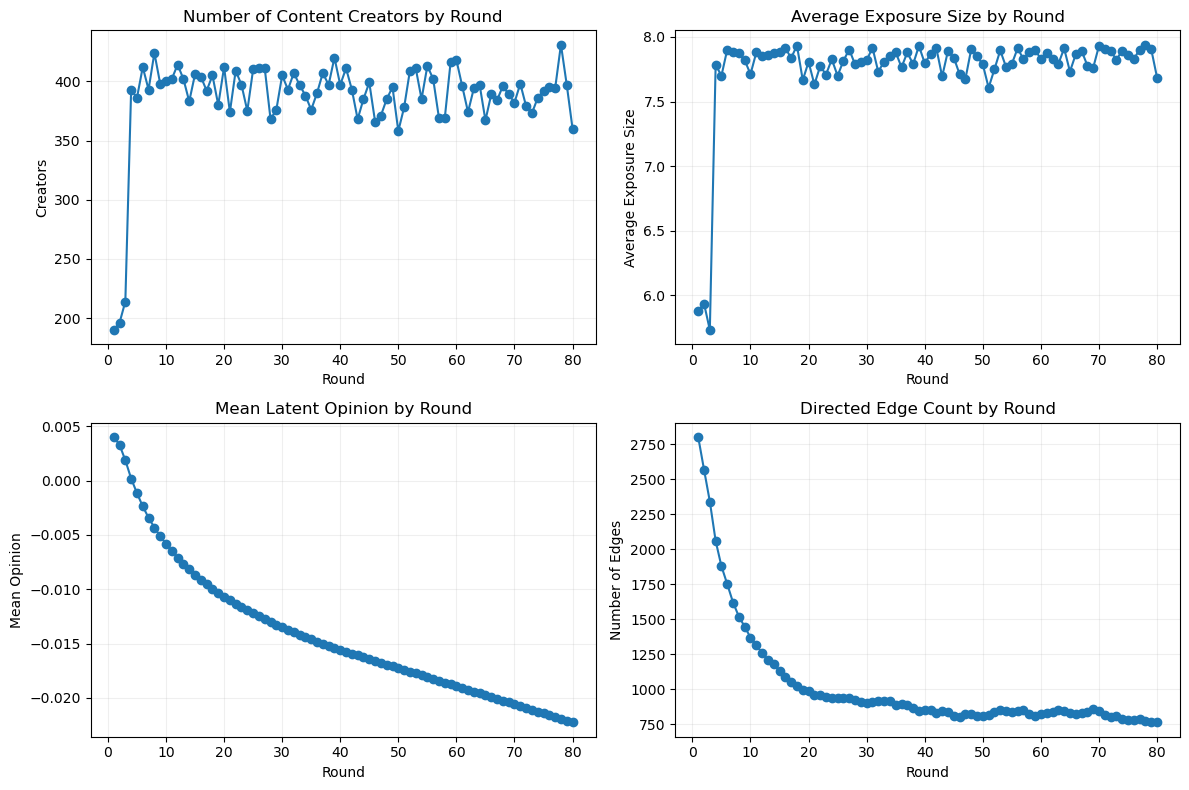

In [8]:
# ==========================================
# Cell 8: Plot time-series summaries over rounds
# ==========================================

fig, _ = plot_time_series_summaries(history_df)
plt.show()


In [9]:
# ==========================================
# Cell 9: Prepare final-round graph for visualization
# ==========================================

G_updated = prepare_graph_for_visualization(G, agents)
final_posts = all_posts_by_round[params['T_rounds']]
final_exposure_sets = all_exposure_sets_by_round[params['T_rounds']]

print('Final round prepared for visualization.')
print(f"Final number of edges: {G_updated.number_of_edges()}")


Final round prepared for visualization.
Final number of edges: 764


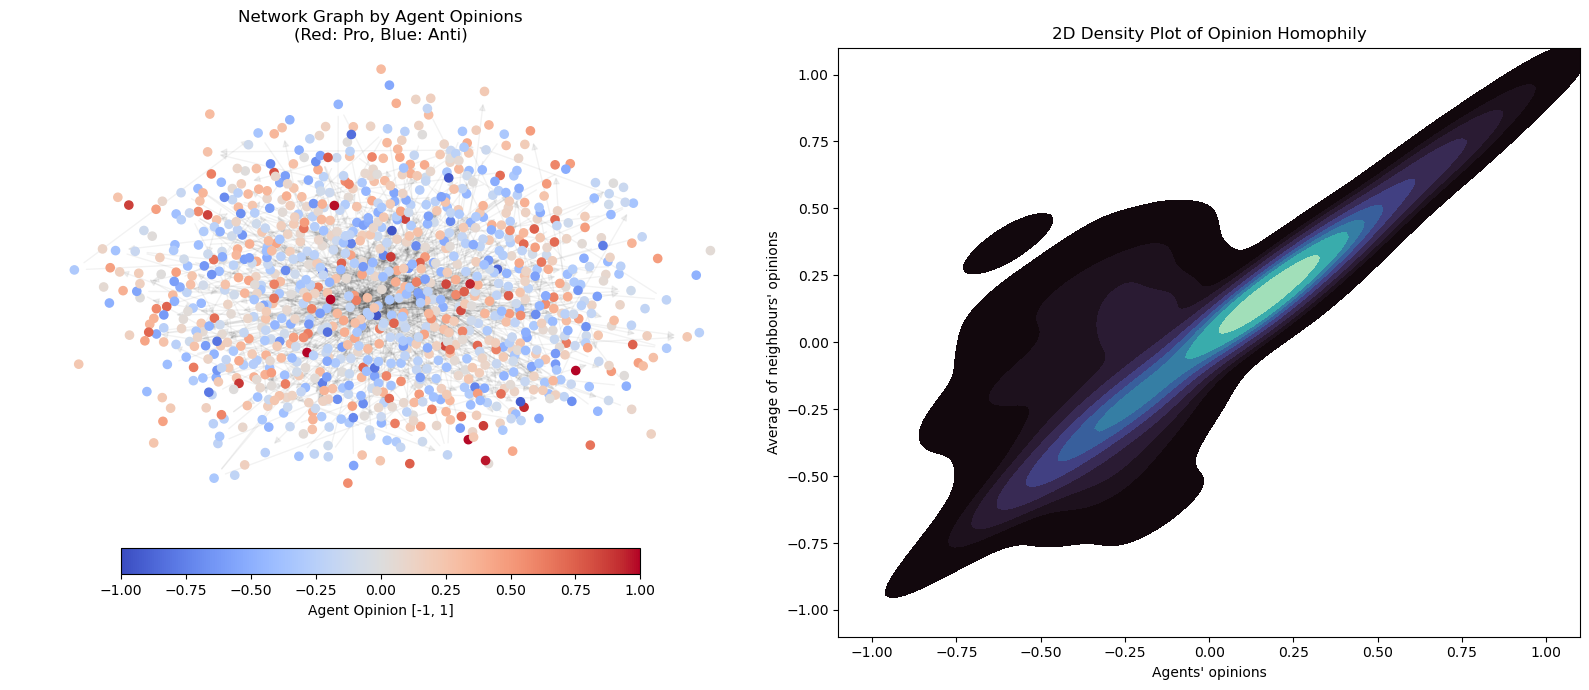

In [10]:
# ==========================================
# Cell 10: 1x2 visualization
# ==========================================

fig, _ = plot_network_and_homophily(G_updated, pos)
plt.show()


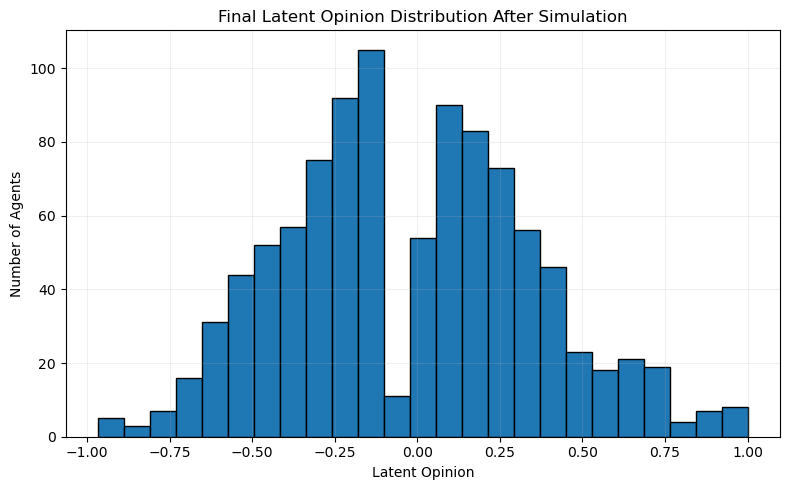

In [11]:
# ==========================================
# Cell 11: Final opinion distribution
# ==========================================

fig, _ = plot_final_opinion_distribution(agents)
plt.show()


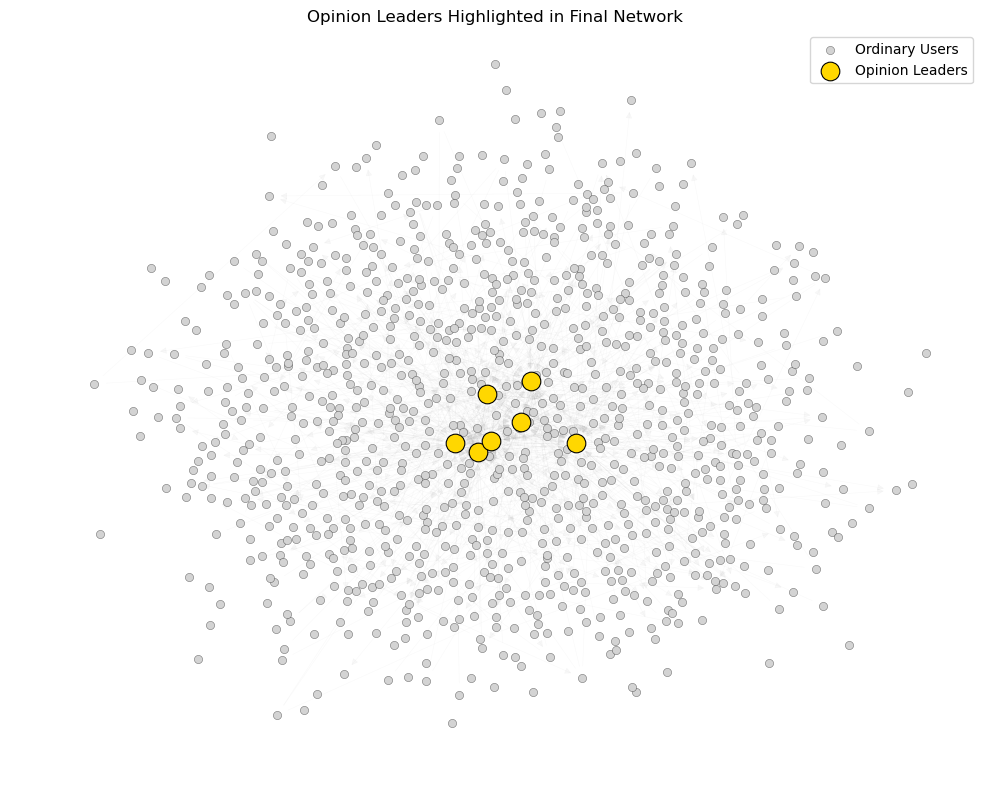

In [12]:
# ==========================================
# Cell 12: Highlight opinion leaders
# ==========================================

fig, _ = plot_opinion_leaders(G_updated, agents, pos)
plt.show()
